In [48]:
import numpy as np
import pandas as pd
from collections import defaultdict
import seaborn as sns
import matplotlib.pyplot as plt

### Convert Multiline FASTA to Single-line FASTA Format

Many times, it is annoying to find sequences of interest because of fix-width format, i.e., if 60 character fix-width file is there then only except the header (starting with >) of the sequence each line will have 60 characters. So, if a sequence is of width 600, then it would be written in 10 lines. The goal is convert this format to a format with header in a single line followed by its sequence in a single line.

### Convert and Save Single-line FASTA File
This code reads the original multiline FASTA file and writes a new FASTA file with sequences in single lines.

In [49]:
def flatten_fasta(input_path, output_path):
    """
    Read a FASTA file where sequences may span multiple lines,
    and write a new FASTA file in which each sequence is on a single line.
    """
    with open(input_path, 'r') as src, open(output_path, 'w') as dst:
        header = None
        seq_buffer = []

        for line in src:
            line = line.rstrip('\n')
            if line.startswith('>'):
                if header is not None:
                    dst.write(f"{header}{''.join(seq_buffer)}\n")
                header = line + '\n'
                seq_buffer = []
            else:
                seq_buffer.append(line)

        if header is not None:
            dst.write(f"{header}{''.join(seq_buffer)}\n")

flatten_fasta("multiline_input.fasta", "singleline_input.fasta")

#Markov Transition Matrix Construction

### Steps for constructing markov chain:
1. Transform the FASTA file so each sequence occupies a single line.
2. Merge all sequences into one continuous string.
3. Generate a first-order Markov transition matrix from the combined sequence.
4. Output the resulting transition matrix.

### Load and Prepare the Sequence
Reads the flattened FASTA file, skip the header lines, and join all sequence lines into a single continuous DNA string.

In [50]:
input_fasta = "singleline_input.fasta"
sequence_fragments = []

with open(input_fasta, 'r') as fh:
    for raw in fh:
        line = raw.strip()
        if line and not line.startswith('>'):
            sequence_fragments.append(line)

full_sequence = "".join(sequence_fragments)

### Count Dinucleotide Transitions
We iterate through the sequence and count each dinucleotide (e.g., AT, GC, CG, etc.) to form the basis of our transition matrix.

In [51]:
nucleotides = ['A', 'C', 'G', 'T']
transition_counts = {n: {m: 0 for m in nucleotides} for n in nucleotides}

for current_nt, next_nt in zip(full_sequence, full_sequence[1:]):
    if current_nt in nucleotides and next_nt in nucleotides:
        transition_counts[current_nt][next_nt] += 1

### Normalize to Build the Transition Matrix
For each nucleotide, divide its transition counts by the total number of outgoing transitions from that nucleotide. This produces a row-normalized matrix in which each entry represents the probability of moving from one base to the next.

In [52]:
df_counts = pd.DataFrame.from_dict(
    transition_counts,
    orient='index',
    columns=nucleotides
)

df_counts = df_counts.reindex(index=nucleotides, columns=nucleotides)

row_sums = df_counts.sum(axis=1)

transition_matrix = df_counts.div(row_sums, axis=0)

transition_matrix = transition_matrix.fillna(0.0) #Replace any NaN values

transition_matrix = transition_matrix.astype(float)

### Visualize with Heatmap
We use seaborn to visualize the transition probabilities as a heatmap.

First Order Markov Transition Matrix:


,A,C,G,T
A,0.250870,0.242645,0.264790,0.241696
C,0.246548,0.254438,0.244905,0.254109
G,0.251826,0.247380,0.255637,0.245157
T,0.270936,0.237438,0.250246,0.241379


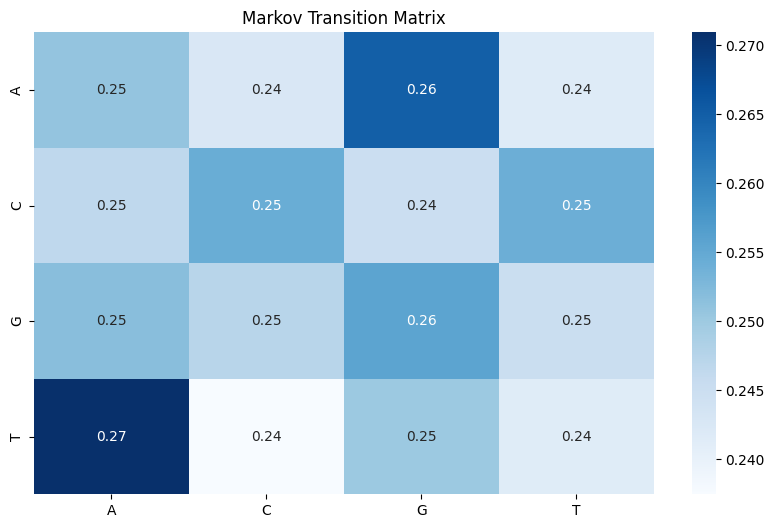

In [53]:
print("First Order Markov Transition Matrix:")
display(transition_matrix)

plt.figure(figsize=(10,6))
sns.heatmap(transition_matrix, annot=True, cmap="Blues", fmt=".2f")
plt.title("Markov Transition Matrix")
plt.show()